In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss,log_loss,classification_report,RocCurveDisplay
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from xgboost import XGBClassifier

In [2]:
import sqlite3
import pandas as pd
import numpy as np

DB_PATH = r"C:\projects\2nd_Semester_Project\data&models\Roma_f1_DB.db"

# ── 1. Load data ──────────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)

data = pd.read_sql("""
    SELECT 
        r.season, r.round, r.circuit_id, r.driver_id, r.team_id,
        q.grid_position AS quali_position,
        r.grid_position AS fallback_grid,
        r.finish_position, r.points, r.status
    FROM race_results r
    LEFT JOIN qualifying q 
        ON r.season = q.season 
        AND r.round = q.round 
        AND r.driver_id = q.driver_id
    WHERE r.finish_position IS NOT NULL
""", conn)

driver_std = pd.read_sql("""
    SELECT season, round, driver_id,
           points as champ_points,
           position as champ_position,
           wins as champ_wins
    FROM driver_standings
""", conn)

team_std = pd.read_sql("""
    SELECT season, round, team_id,
           points as team_points,
           position as team_position
    FROM constructor_standings
""", conn)

conn.close()

data = data.merge(driver_std, on=["season", "round", "driver_id"], how="left")
data = data.merge(team_std,   on=["season", "round", "team_id"],   how="left")
data["grid_position"] = data["quali_position"].fillna(data["fallback_grid"])

In [3]:
wet_data=pd.read_csv(r"C:\projects\2nd_Semester_Project\data&models\wet_races.csv")
wet_data=wet_data[['season','is_wet_race','round']]


data=data.merge(wet_data,on=['season','round'],how='left')
data['is_wet_race']=data['is_wet_race'].fillna(0).astype(int)

In [4]:

data = data.sort_values(["driver_id", "season", "round"]).reset_index(drop=True)

for col in ["champ_points", "champ_position", "champ_wins"]:
    data[col] = data.groupby(["season", "driver_id"])[col].shift(1).fillna(0)

for col in ["team_points", "team_position"]:
    data[col] = data.groupby(["season", "team_id"])[col].shift(1).fillna(0)

data["champ_position"] = data["champ_position"].replace(0, 10)
data["team_position"]  = data["team_position"].replace(0, 5)


#if the finish position is 1 then the driver is the winner 
#if True then is_winner = 1
data["is_winner"] = (data["finish_position"] == 1).astype(int)
#if the finish position is more than 4 then the driver is in podium 
#if True then is_poduim = 1
data["is_podium"] = (data["finish_position"] <= 3).astype(int)

data["dnf"]= (~data["status"].isin(["Finished", "+1 Lap", "+2 Laps"])).astype(int)

In [5]:
def rolling_driver(data, col, window=5):
    return (data.groupby("driver_id")[col]
              .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean()))

#Calculate the AVG of last 5 races for each driver on each feature of the following 
data["avg_finish_last5"]= rolling_driver(data, "finish_position")
data["avg_points_last5"]= rolling_driver(data, "points")
data["avg_grid_last5"]= rolling_driver(data, "grid_position")
data["dnf_rate_last5"]= rolling_driver(data, "dnf")
data["win_rate_last5"]= rolling_driver(data, "is_winner")
data["podium_rate_last5"] = rolling_driver(data, "is_podium")

In [6]:
data = data.sort_values(["driver_id", "circuit_id", "season", "round"])
data["circuit_win_rate"] = (
    data.groupby(["driver_id", "circuit_id"])["is_winner"]
      .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
      .fillna(0)
)
data = data.sort_values(["driver_id", "season", "round"]).reset_index(drop=True)

# Season stage — 0.0 at first race, 1.0 at last race
max_rounds = data.groupby("season")["round"].transform("max")
data["season_stage"]= data["round"] / max_rounds

# 1 if driver starts from pole or 2nd 
data["front_row"]= (data["grid_position"] <= 2).astype(int)

# 1 if driver starts in top 5
data["top5_grid"]= (data["grid_position"] <= 5).astype(int)

#Relative grid advantage vs championship position
#Negative means better
data["grid_vs_champ"]=data["grid_position"] - data["champ_position"]

#how much points has the team been scoring recently
data["team_avg_points_last5"] = (
    data.groupby("team_id")["points"]
      .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

In [7]:
data.sort_values(by=['season','round'],inplace=True)

#The AVG score of the drviver for the last 3 races
data['driver_recent_points']=data.groupby('driver_id')['points'].transform(
    lambda x : x.shift(1).rolling(window=3,min_periods=1).mean()
)
#The AVG socre of the driver for each circuit
data['driver_circut_avg']=data.groupby(['driver_id','circuit_id'])['finish_position'].transform(
    lambda x: x.shift(1).expanding().mean()
)
#The SUM of the team points for all season
data['team_season_points']=data.groupby(['team_id','season'])['points'].transform(
    lambda x: x.shift(1).expanding().sum()
)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6899 entries, 129 to 6355
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   season                 6899 non-null   int64  
 1   round                  6899 non-null   int64  
 2   circuit_id             6899 non-null   object 
 3   driver_id              6899 non-null   object 
 4   team_id                6899 non-null   object 
 5   quali_position         6484 non-null   float64
 6   fallback_grid          6877 non-null   float64
 7   finish_position        6899 non-null   int64  
 8   points                 6899 non-null   float64
 9   status                 6899 non-null   object 
 10  champ_points           6899 non-null   float64
 11  champ_position         6899 non-null   float64
 12  champ_wins             6899 non-null   float64
 13  team_points            6899 non-null   float64
 14  team_position          6899 non-null   float64
 15  grid_po

In [9]:
le_circuit = LabelEncoder()
le_team = LabelEncoder()
oh_driver=OneHotEncoder(sparse_output=False,handle_unknown='ignore')

driver_id_encoded=oh_driver.fit_transform(data[['driver_id']])
driver_encoded_cols = oh_driver.get_feature_names_out(['driver_id'])
river_encoded_df = pd.DataFrame(driver_id_encoded, columns=driver_encoded_cols, index=data.index)
data = pd.concat([data, river_encoded_df], axis=1)

data['circuit_id_encoded'] = le_circuit.fit_transform(data['circuit_id'].astype(str))
data['team_id_encoded'] = le_team.fit_transform(data['team_id'].astype(str))

base_features = [
    "grid_position", "champ_points", "champ_position", "champ_wins",
    "team_points", "team_position", "avg_finish_last5", "avg_points_last5",
    "avg_grid_last5", "dnf_rate_last5", "win_rate_last5", "podium_rate_last5",
    "circuit_win_rate", "season_stage", "front_row", "top5_grid",
    "grid_vs_champ", "team_avg_points_last5", "driver_circut_avg",
    "driver_recent_points","circuit_id_encoded","team_id_encoded"
]
FEATURES = base_features + list(driver_encoded_cols)

data[FEATURES] = data[FEATURES].fillna(data[FEATURES].median())

# Evaluations

In [10]:
def top1_accuracy(model, X_test, test_df):
    test_df = test_df.copy().reset_index(drop=True)
    X_test  = X_test.reset_index(drop=True)
 
    test_df["pred_proba"] = model.predict_proba(X_test)[:, 1]
 
    correct, total = 0, 0
    for (season, round_), group in test_df.groupby(["season", "round"]):
        actual_winner    = group[group["is_winner"] == 1]["driver_id"].values
        predicted_winner = group.nlargest(1, "pred_proba")["driver_id"].values
        if len(actual_winner) == 0:
            continue
        if actual_winner[0] == predicted_winner[0]:
            correct += 1
        total += 1
 
    accuracy = correct / total if total > 0 else 0.0
    print(f"Top-1 Accuracy: {accuracy:.4f} ({correct}/{total} races)")
    return accuracy

In [11]:
def top3_accuracy(model, X_test, test_df):
    test_df = test_df.copy().reset_index(drop=True)
    X_test  = X_test.reset_index(drop=True)
 
    test_df["pred_proba"] = model.predict_proba(X_test)[:, 1]
 
    correct, total = 0, 0
    misses = []
 
    for (season, round_), group in test_df.groupby(["season", "round"]):
        actual_winner = group[group["is_winner"] == 1]["driver_id"].values
        if len(actual_winner) == 0:
            continue
 
        top3_predicted = group.nlargest(3, "pred_proba")["driver_id"].values
 
        if actual_winner[0] in top3_predicted:
            correct += 1
        else:
            misses.append({
                "season": season,
                "round":  round_,
                "actual": actual_winner[0],
                "predicted_top3": list(top3_predicted)
            })
        total += 1
        
 
    accuracy = correct / total if total > 0 else 0.0
    print(f"Top-3 Accuracy:  {accuracy:.4f} ({correct}/{total} races)")
    
    if misses:
        print(f"\nMissed races ({len(misses)}):")
        for m in misses[:7]:
            print(f"  {m['season']} R{m['round']}: actual={m['actual']}, predicted={m['predicted_top3']}")

    return accuracy


In [12]:
def evaluate_classifier(model, X_test, y_test, label):
    proba = model.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    
    # Probability Quality
    print(f"\n── {label} ──")
    print(f"Brier score: {brier_score_loss(y_test, proba):.4f}") # The difference is squared Like MSE
    print(f"Log loss:    {log_loss(y_test, proba):.4f}") # Cross-Entropy
    
    # Ranking / Threshold Performance
    RocCurveDisplay.from_estimator(model,X_test,y_test,ax = plt.gca(),name=label)
    # Compares between True Positive Rate, False Positive Rate
    plt.title('ROC Curve Comparison: Formula 1 Prediction')
    
    # Classification Quality
    print(classification_report(y_test, pred))
    # Precision, Recall, F1-score

In [13]:
y_winner = data["is_winner"]
y_podium = data["is_podium"]

train_mask = data["season"] <= 2023
test_mask  = data["season"].isin([2024, 2025])
live_mask  = data["season"] == 2026

x_train = data.loc[train_mask, FEATURES]
x_test  = data.loc[test_mask,  FEATURES]
x_live  = data.loc[live_mask,  FEATURES]

y_train_winner = y_winner[train_mask]
y_test_winner  = y_winner[test_mask]

y_train_podium = y_podium[train_mask]
y_test_podium  = y_podium[test_mask]

In [14]:
# Exponential Time Decay
#give each season a weight decay from 2025 to 2010
def compute_weights(seasons, decay_factor=0.85):
    weights = np.ones(len(seasons))
    pre_mask = seasons < 2026
    years_back = 2025 - seasons[pre_mask]
    weights[pre_mask] = decay_factor ** years_back
    return weights

weights_train = compute_weights(
    data.loc[train_mask, "season"].values,
    decay_factor=0.85
)

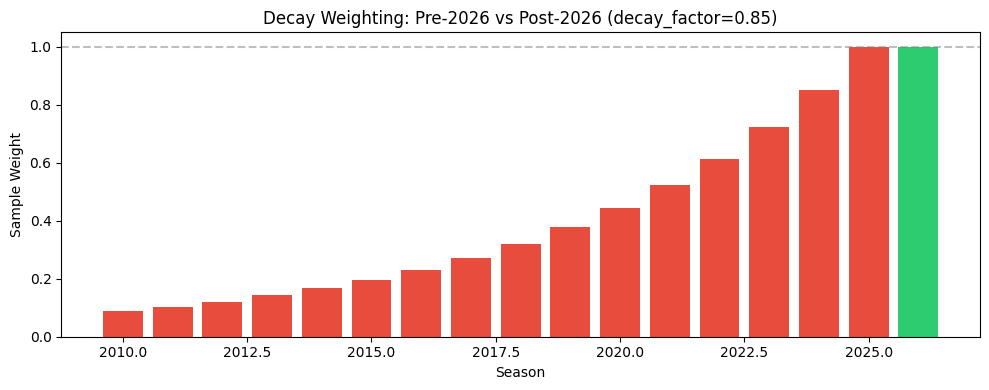

In [15]:
seasons_range = np.arange(2010, 2027)
weights_viz   = compute_weights(seasons_range, decay_factor=0.85)
 
plt.figure(figsize=(10, 4))
plt.bar(seasons_range, weights_viz, color=["#e74c3c" if s < 2026 else "#2ecc71" for s in seasons_range])
plt.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("Season")
plt.ylabel("Sample Weight")
plt.title("Decay Weighting: Pre-2026 vs Post-2026 (decay_factor=0.85)")
plt.tight_layout()
plt.savefig(r"C:\projects\2nd_Semester_Project\roma_decay_weights.png", dpi=150)
plt.show()


In [16]:
winner_ratio = (y_train_winner == 0).sum() / (y_train_winner == 1).sum()
podium_ratio = (y_train_podium == 0).sum() / (y_train_podium == 1).sum()

print(f"Winner imbalance ratio = {winner_ratio:.2f}")
print(f"Podium imbalance ratio = {podium_ratio:.2f}")

Winner imbalance ratio = 20.21
Podium imbalance ratio = 6.07


In [17]:
winner_model = XGBClassifier(n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1,
    scale_pos_weight=winner_ratio,
    eval_metric="logloss",
    verbosity=0)
winner_model.fit(x_train, y_train_winner, sample_weight=weights_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [18]:
podium_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1,
    scale_pos_weight=podium_ratio,
    eval_metric="logloss",
    verbosity=0
)
podium_model.fit(x_train, y_train_podium, sample_weight=weights_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'



── Winner Model ──
Brier score: 0.0433
Log loss:    0.1485
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       910
           1       0.43      0.62      0.51        48

    accuracy                           0.94       958
   macro avg       0.71      0.79      0.74       958
weighted avg       0.95      0.94      0.95       958


── Podium Model ──
Brier score: 0.0879
Log loss:    0.2923
              precision    recall  f1-score   support

           0       0.97      0.88      0.92       814
           1       0.55      0.82      0.66       144

    accuracy                           0.87       958
   macro avg       0.76      0.85      0.79       958
weighted avg       0.90      0.87      0.88       958



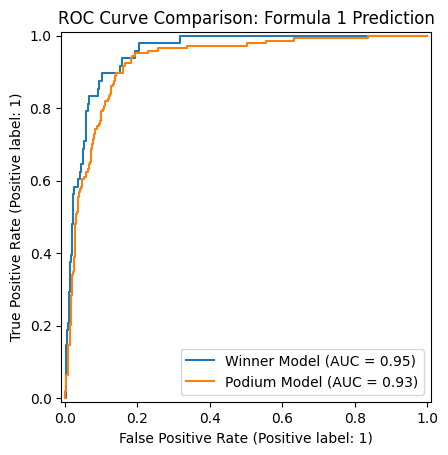

In [19]:
test_df = data[test_mask].copy()
evaluate_classifier(winner_model, x_test, y_test_winner,  "Winner Model")
evaluate_classifier(podium_model, x_test, y_test_podium,  "Podium Model")

In [20]:
top1_baseline = top1_accuracy(winner_model, x_test, test_df)
top3_baseline = top3_accuracy(winner_model, x_test, test_df)

Top-1 Accuracy: 0.5000 (24/48 races)
Top-3 Accuracy:  0.8542 (41/48 races)

Missed races (7):
  2024 R6: actual=norris, predicted=['max_verstappen', 'perez', 'sainz']
  2024 R12: actual=hamilton, predicted=['russell', 'max_verstappen', 'norris']
  2024 R14: actual=hamilton, predicted=['max_verstappen', 'norris', 'leclerc']
  2024 R16: actual=leclerc, predicted=['norris', 'piastri', 'max_verstappen']
  2024 R19: actual=leclerc, predicted=['norris', 'max_verstappen', 'sainz']
  2024 R21: actual=max_verstappen, predicted=['norris', 'russell', 'tsunoda']
  2025 R6: actual=piastri, predicted=['max_verstappen', 'norris', 'kimi_antonelli']


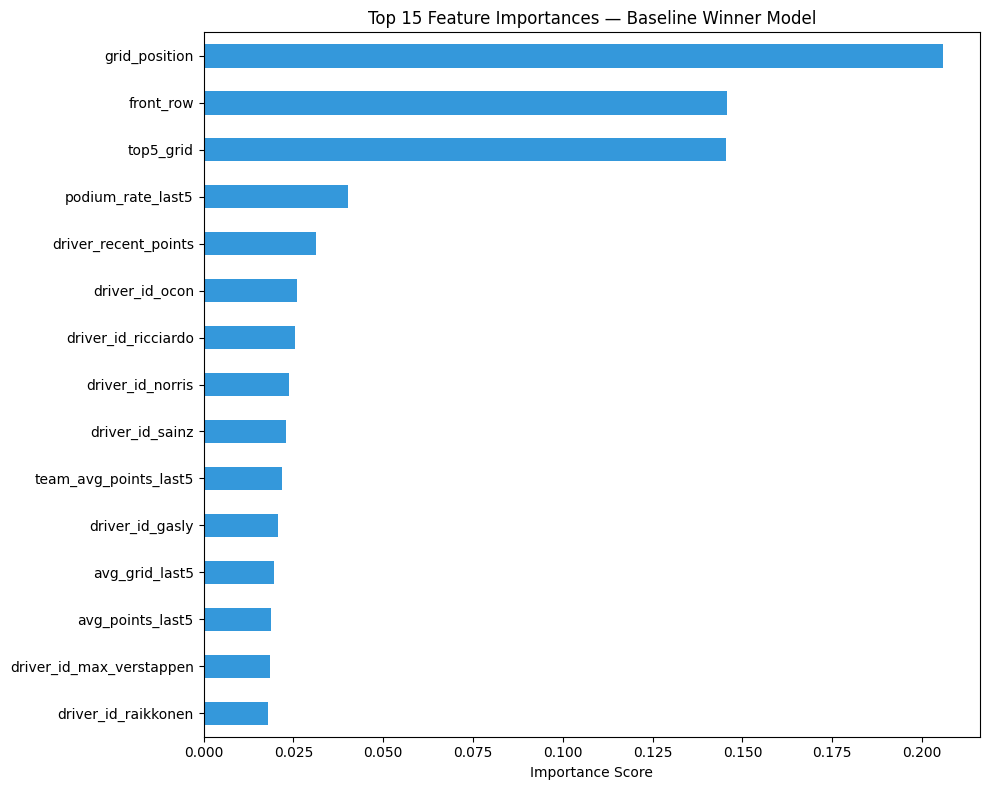

In [21]:
feat_importance = pd.Series(
    winner_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)
 
plt.figure(figsize=(10, 8))
feat_importance.head(15).plot(kind="barh", color="#3498db")
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances — Baseline Winner Model")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r"C:\projects\2nd_Semester_Project\roma_feature_importance.png", dpi=150)
plt.show()

In [22]:
FINALFEATURES=feat_importance[feat_importance>=0.01].index.tolist()

In [23]:
X_clean = data[FINALFEATURES]
X_train, X_test, X_live = X_clean[train_mask], X_clean[test_mask],X_clean[live_mask]
winner_model.fit(X_train, y_train_winner, sample_weight=weights_train)
podium_model.fit(X_train,y_train_podium,sample_weight=weights_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [24]:
top1_baseline = top1_accuracy(winner_model, X_test, test_df)
top3_baseline = top3_accuracy(winner_model, X_test, test_df)

Top-1 Accuracy: 0.5833 (28/48 races)
Top-3 Accuracy:  0.8750 (42/48 races)

Missed races (6):
  2024 R6: actual=norris, predicted=['max_verstappen', 'perez', 'leclerc']
  2024 R14: actual=hamilton, predicted=['max_verstappen', 'norris', 'leclerc']
  2024 R16: actual=leclerc, predicted=['norris', 'piastri', 'max_verstappen']
  2024 R19: actual=leclerc, predicted=['norris', 'max_verstappen', 'piastri']
  2024 R21: actual=max_verstappen, predicted=['norris', 'russell', 'tsunoda']
  2025 R23: actual=max_verstappen, predicted=['piastri', 'norris', 'kimi_antonelli']



── WinnerModel ──
Brier score: 0.0478
Log loss:    0.1610
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       910
           1       0.44      0.79      0.57        48

    accuracy                           0.94       958
   macro avg       0.72      0.87      0.77       958
weighted avg       0.96      0.94      0.95       958



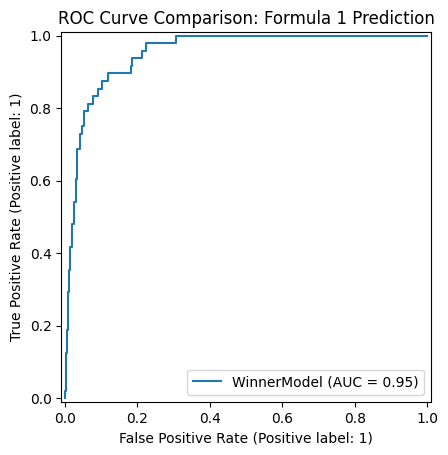

In [25]:
evaluate_classifier(winner_model,X_test,y_test_winner,"WinnerModel")

In [26]:
import pyswarms as ps
from pyswarms.single import GlobalBestPSO
from pyswarms.utils.plotters import plot_cost_history

In [27]:
def fitness_function(params_matrix):
    
    costs = []

    for params in params_matrix:
        n_estimators     = int(np.clip(params[0], 100, 800))
        max_depth        = int(np.clip(params[1], 3, 10))
        learning_rate    = float(np.clip(params[2], 0.01, 0.30))
        subsample        = float(np.clip(params[3], 0.5, 1.0))
        colsample_bytree = float(np.clip(params[4], 0.5, 1.0))
        min_child_weight = int(np.clip(params[5], 1, 8))
        reg_alpha        = float(np.clip(params[6], 0.0, 1.0))
        reg_lambda       = float(np.clip(params[7], 0.5, 2.0))
        decay_factor     = float(np.clip(params[8], 0.70, 1.00))
        

        w = compute_weights(
            data.loc[train_mask, "season"].values,
            decay_factor=decay_factor
        )

        model = XGBClassifier(
            n_estimators     = n_estimators,
            max_depth        = max_depth,
            learning_rate    = learning_rate,
            subsample        = subsample,
            colsample_bytree = colsample_bytree,
            min_child_weight = min_child_weight,
            reg_alpha        = reg_alpha,
            reg_lambda       = reg_lambda,
            scale_pos_weight = winner_ratio,
            random_state     = 42,
            eval_metric      = "logloss",
            verbosity        = 0,
        )

        model.fit(X_train, y_train_winner, sample_weight=w)
        proba = model.predict_proba(X_test)[:, 1]
        cost  = log_loss(y_test_winner, proba)
        costs.append(cost)

    return np.array(costs)


In [28]:
lower_bounds = np.array([100,  3, 0.01, 0.50, 0.50, 1, 0.0, 0.5, 0.70])
upper_bounds = np.array([800, 10, 0.30, 1.00, 1.00, 8, 1.0, 2.0, 1.00])
bounds = (lower_bounds, upper_bounds)
options = {
    "c1": 0.5,  

    "c2": 0.3,
                

    "w":  0.9, 
                
}

In [29]:
optimizer = GlobalBestPSO(
    n_particles = 20,
    dimensions  = 9,
    options     = options,
    bounds      = bounds,
)

best_cost, best_params = optimizer.optimize(
    fitness_function,
    iters   = 30,
    verbose = True,  # prints progress every iteration
)

2026-05-13 18:08:03,107 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.133
2026-05-13 18:22:39,039 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.13298530826999502, best pos: [3.55474046e+02 7.06012931e+00 8.91165929e-02 6.03024601e-01
 7.14850883e-01 2.89512278e+00 6.94675265e-01 1.17563459e+00
 9.44214036e-01]


In [30]:
best_n_estimators     = int(np.clip(best_params[0], 100, 800))
best_max_depth        = int(np.clip(best_params[1], 3, 10))
best_learning_rate    = float(best_params[2])
best_subsample        = float(best_params[3])
best_colsample        = float(best_params[4])
best_min_child_weight = int(np.clip(best_params[5], 1, 8))
best_reg_alpha        = float(best_params[6])
best_reg_lambda       = float(best_params[7])
best_decay_factor     = float(best_params[8])

In [31]:
optimized_weights = compute_weights(
    data.loc[train_mask, "season"].values,
    decay_factor=best_decay_factor
)

pso_winner_model = XGBClassifier(
    n_estimators     = best_n_estimators,
    max_depth        = best_max_depth,
    learning_rate    = best_learning_rate,
    subsample        = best_subsample,
    colsample_bytree = best_colsample,
    min_child_weight = best_min_child_weight,
    reg_alpha        = best_reg_alpha,
    reg_lambda       = best_reg_lambda,
    scale_pos_weight = winner_ratio,
    random_state     = 42,
    eval_metric      = "logloss",
    verbosity        = 0,
)
pso_winner_model.fit(X_train, y_train_winner, sample_weight=optimized_weights)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7148508829450708
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'



── PSO(model) ──
Brier score: 0.0384
Log loss:    0.1330
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       910
           1       0.47      0.54      0.50        48

    accuracy                           0.95       958
   macro avg       0.72      0.75      0.74       958
weighted avg       0.95      0.95      0.95       958

Top-1 Accuracy: 0.5625 (27/48 races)


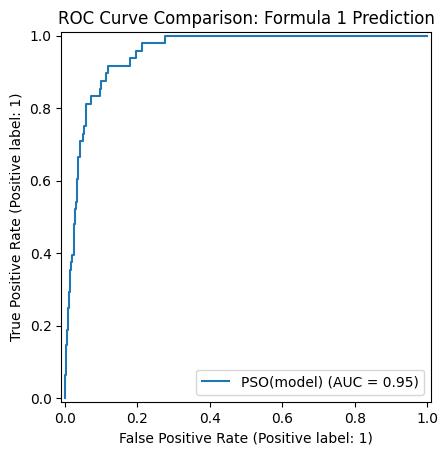

In [33]:
test_df_reset = data[test_mask].copy()
evaluate_classifier(pso_winner_model,X_test,y_test_winner,"PSO(model)")

top_1_PSO=top1_accuracy(pso_winner_model,X_test,test_df_reset)

In [ ]:
import joblib
joblib.dump(le_circuit,r"C:\projects\2nd_Semester_Project\LabelE_circuit.pkl")
joblib.dump(le_team,r"C:\projects\2nd_Semester_Project\LabelE_team.pkl")
joblib.dump(pso_winner_model,r"C:\projects\2nd_Semester_Project\roma_winner_model_pso.pkl")
joblib.dump(winner_model,r"C:\projects\2nd_Semester_Project\roma_best_model.pkl")
joblib.dump(best_params,r"C:\projects\2nd_Semester_Project\roma_pso_best_params.pkl")
joblib.dump(FINALFEATURES,r"C:\projects\2nd_Semester_Project\roma_features.pkl")

['C:\\projects\\2nd_Semester_Project\\roma_features.pkl']

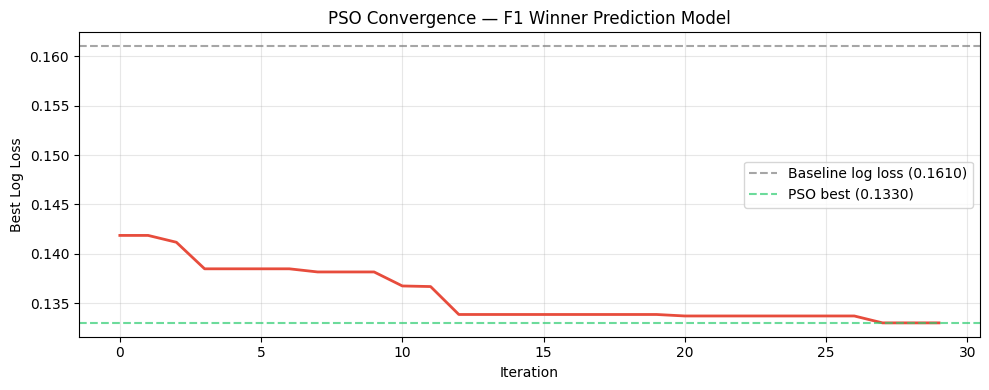

In [34]:
baseline_logloss=log_loss(y_test_winner, winner_model.predict_proba(X_test)[:,1])
plt.figure(figsize=(10, 4))
plt.plot(optimizer.cost_history, color="#e74c3c", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Best Log Loss")
plt.title("PSO Convergence — F1 Winner Prediction Model")
plt.grid(True, alpha=0.3)
plt.axhline(
    y=baseline_logloss,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label=f"Baseline log loss ({baseline_logloss:.4f})"
)
plt.axhline(
    y=best_cost,
    color="#2ecc71",
    linestyle="--",
    alpha=0.7,
    label=f"PSO best ({best_cost:.4f})"
)
plt.legend()
plt.tight_layout()
plt.show()